---
---

<h1><center><ins>Exercise Sheet 7</ins></center></h1>
<h2><center>Numerical Methods <br><br>

---
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import exp

## Exercise 1 - Backward Euler:

Consider the following first-order ODE:

$$ \frac{d y}{dt} = - 3 y \ , $$

**(A)** Solve this ODE with **your own forward Euler** implementation for $0\leq t\leq20$. Use the following step sizes: $\Delta t = 0.1, 0.25, 0.5, 0.75$, and plot the numerical solution for all four step sizes in four different figures. Also compare it with the exact analytical solution in the corresponding plot. Discuss your findings.

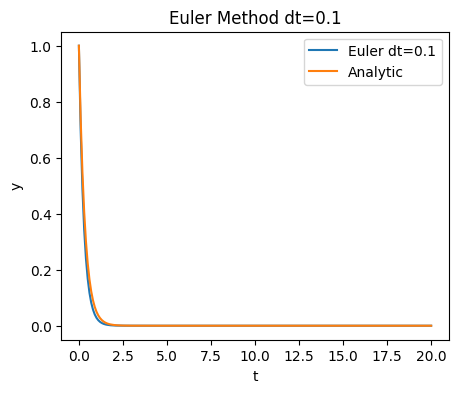

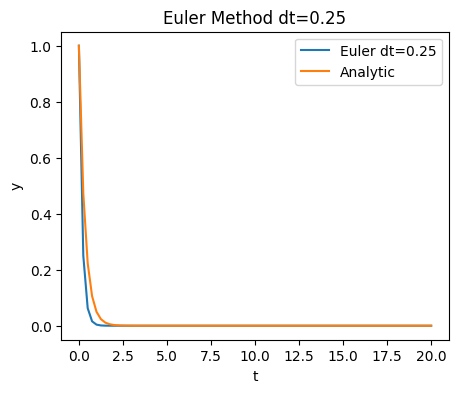

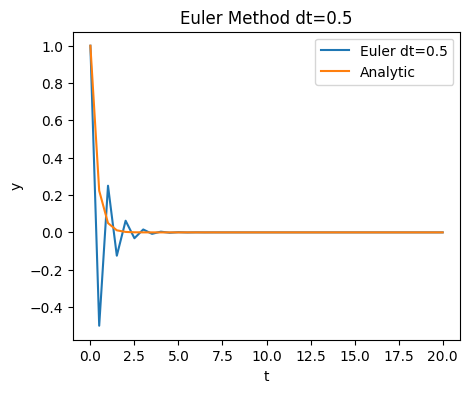

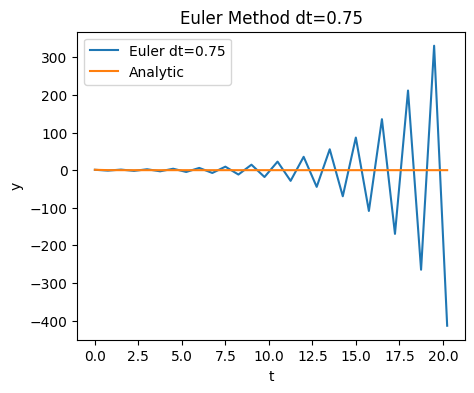

In [8]:
def feuler(y0, t_max, dt):
    t = np.arange(0, t_max + dt, dt)
    y = np.zeros_like(t)
    y[0] = y0

    for i in range(len(t) - 1):
        y[i+1] = y[i] + dt * (-3 * y[i])
    return t, y


dts = [0.1, 0.25, 0.5, 0.75]

for dt in dts:
    y0 = 1
    t, y = feuler(y0, 20, dt)
    y_exact = y0*exp(-3 * t)

    plt.figure(figsize=(5,4))
    plt.plot(t, y, label=f"Euler dt={dt}")
    plt.plot(t, y_exact, label="Analytic")
    plt.legend()
    plt.xlabel("t")
    plt.ylabel("y")
    plt.title(f"Euler Method dt={dt}")
    #plt.yscale("log")
    plt.show()


**(B)** Now implement **your own backward Euler** implementation and repeat all the steps from **(A)**. What do you notice?

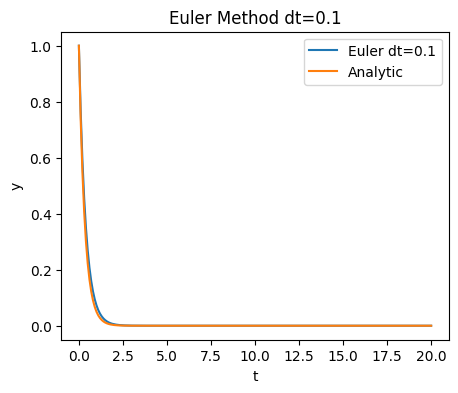

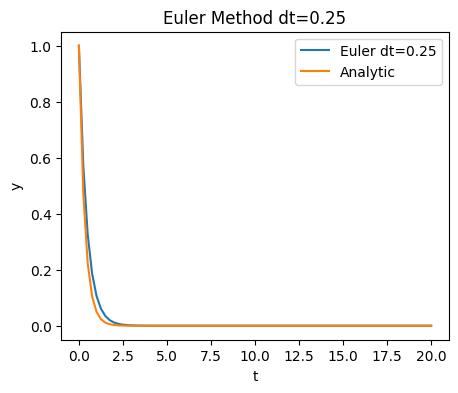

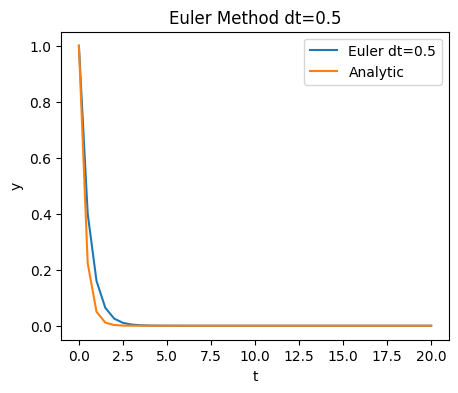

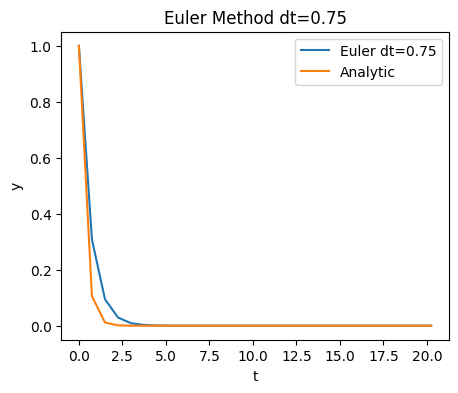

In [9]:
def beuler(y0, t_max, dt):
    t = np.arange(0, t_max + dt, dt)
    y = np.zeros_like(t)
    y[0] = y0

    for i in range(len(t) - 1):
        y[i+1] = y[i] / (1 + 3*dt)
    return t, y

for dt in dts:
    y0 = 1
    t, y = beuler(y0, 20, dt)
    y_exact = y0*np.exp(-3 * t)

    plt.figure(figsize=(5,4))
    plt.plot(t, y, label=f"Euler dt={dt}")
    plt.plot(t, y_exact, label="Analytic")
    plt.legend()
    plt.xlabel("t")
    plt.ylabel("y")
    plt.title(f"Euler Method dt={dt}")
    #plt.yscale("log")

plt.show()


**(C)** What complication arises in the implementation of the backward Euler, if we replace the right hand side of the ODE with $ (1-\frac{y}{3})y $? What kind of numerical methods already known from the lecture can you use to solve the arising equation? Please implement them to solve this ODE with the backward Euler and compare your solution with analytic one by plotting them in a figure.

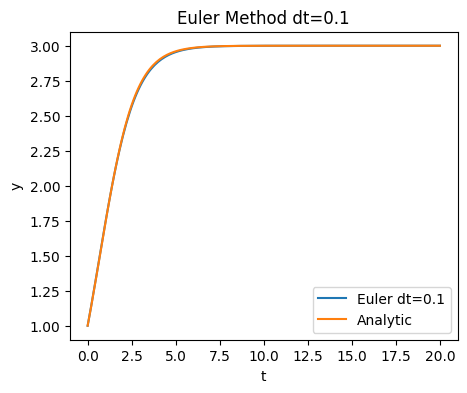

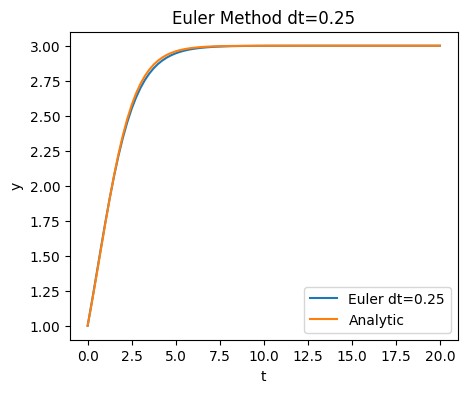

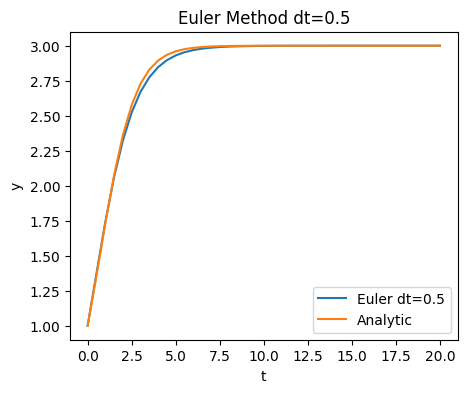

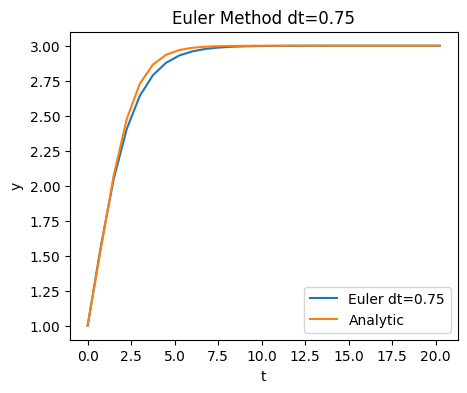

In [10]:
# dy/dt = (1-y/3)y
# y_i+1 = y_i + dt*(1 - y_i+1 / 3)*y_i+1
# y_i+1 - y_i - dt*(1-y_i+1 / 3)*y_i+1 = 0
# non linear (e.g. Newton-Raphson)


# Parameters
y0 = 1
t_max = 5
dt = 0.1


y_exact = lambda t: 3/(1 + (3/y0 - 1)*np.exp(-t))
f = lambda y0, y1: y1 - y0 - dt*(1-y1/3)*y1
df = lambda y1: 1- dt*(1 - 2/3 * y1)

def newton_raphson(y0, y1_init, tol=1e-8, max_iter=1000):
    y1 = y1_init
    for i in range(max_iter):
        if abs(df(y1)) < 1e-12:
            print("Derivative near zero in Newton-Raphson method.")
            return y1
        y1_new = y1 - f(y0, y1)/df(y1)
        if abs(f(y0, y1_new)) < tol or abs(y1_new - y1) < tol:
            return y1_new
        y1 = y1_new
    print("Newton-Raphson did not converge.")

def beuler2(y0, t_max, dt):
    t = np.arange(0, t_max + dt, dt)
    y = np.zeros_like(t)
    y[0] = y0

    for i in range(len(t) - 1):
        y[i+1] = newton_raphson(y[i], y[i])
    return t, y




for dt in dts:
    t, y = beuler2(y0, 20, dt)
    y_ex = y_exact(t)

    plt.figure(figsize=(5,4))
    plt.plot(t, y, label=f"Euler dt={dt}")
    plt.plot(t, y_ex, label="Analytic")
    plt.legend()
    plt.xlabel("t")
    plt.ylabel("y")
    plt.title(f"Euler Method dt={dt}")

plt.show()

## Exercise 2 - Backward Euler Part 2:

Consider now the following second-order ODE:

$$ y^{\prime\prime} + 6 y^{\prime} + 5y = 10, $$

with initial conditions of $y(0) = 0$ and $y^{\prime}(0) = 5.$

**(A)** Solve this ODE with **your own backward Euler** implementation for $0\leq t\leq5$. What is the linear system of equation that you have to solve? (write it down in matrix notation). Within **your own backward Euler** implementation you are free to solve this system of equation using either numerical methods (e.g. np.linalg.solve) or invert the matrix by hand. Use a step size of 0.1 and 0.5. Plot the absolute error of the numerical solutions for both steps sizes compared to the exact solution. The exact solution is 

$$ y(t) = -\frac{3}{4}e^{-5t} -\frac{5}{4}e^{-t} + 2. $$




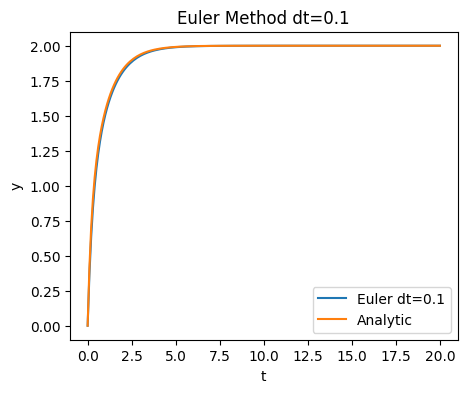

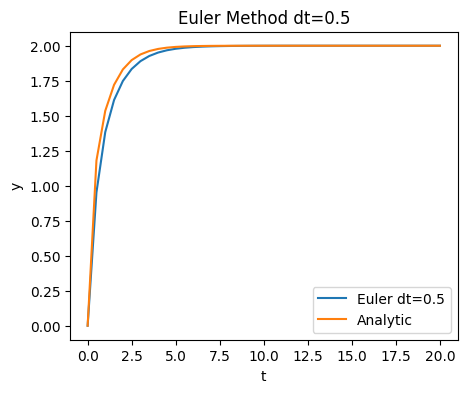

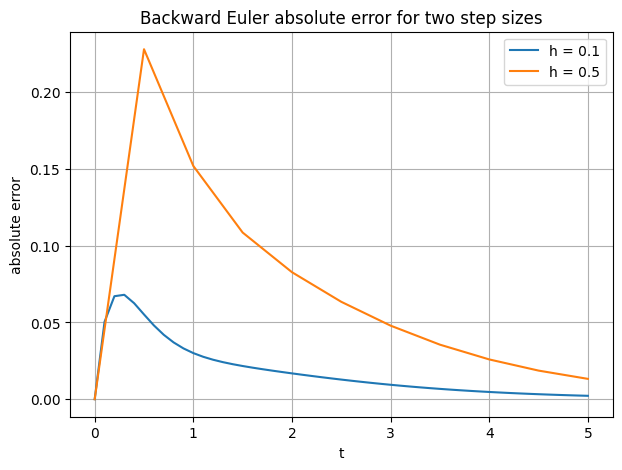

In [5]:
from numpy import linalg

y0, v0 = 0, 5

y_exact = lambda t: -3/4*exp(-5*t) - 5/4*exp(-t) + 2

# y' = v
# v' = 10 - 6v - 5y
# yn+1 = yn + h(vn+1)
# vn+1 = vn + h(10 - 6vn+1 - 5yn+1)

# (  yn  ) = (1    -h ) (yn+1)
# (vn+10h) = (5h  1+6h) (vn+1)

def beuler3(y0, v0, t_max, dt):
    t = np.arange(0, t_max + dt, dt)
    y = np.zeros_like(t)
    v = np.zeros_like(t)
    y[0] = y0
    v[0] = v0

    for i in range(len(t) - 1):
        A = np.array([[1, -dt], [5*dt, 1 + 6*dt]])
        b = np.array([y[i], v[i] + 10*dt])
        x = linalg.solve(A, b)
        y[i+1], v[i+1] =  x
    return t, y



dts2 = [0.1, 0.5]

for dt in dts2:
    t, y = beuler3(y0, v0, 20, dt)
    y_ex = y_exact(t)

    plt.figure(figsize=(5,4))
    plt.plot(t, y, label=f"Euler dt={dt}")
    plt.plot(t, y_ex, label="Analytic")
    plt.legend()
    plt.xlabel("t")
    plt.ylabel("y")
    plt.title(f"Euler Method dt={dt}")

plt.show()

plt.figure(figsize=(7,5))

for dt in dts2:
    t, y_num = beuler3(y0, v0, t_max, dt)
    y_ex = y_exact(t)
    error = np.abs(y_num - y_ex)

    plt.plot(t, error, label=f"h = {dt}")

plt.xlabel("t")
plt.ylabel("absolute error")
plt.title("Backward Euler absolute error for two step sizes")
plt.grid(True)
plt.legend()
plt.show()

**(B)** Repeat **(A)** using **forward Euler**. What do you notice?

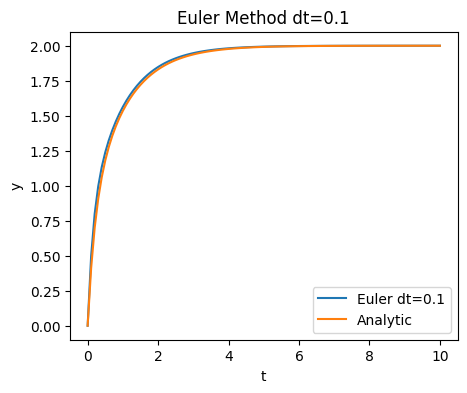

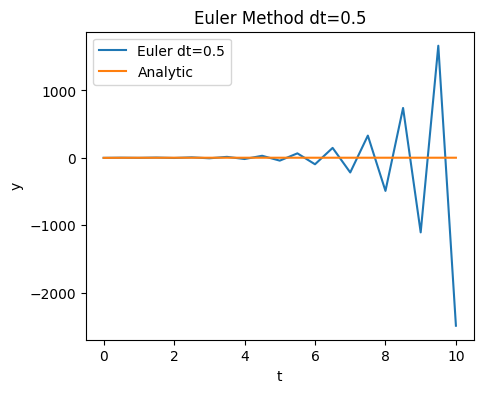

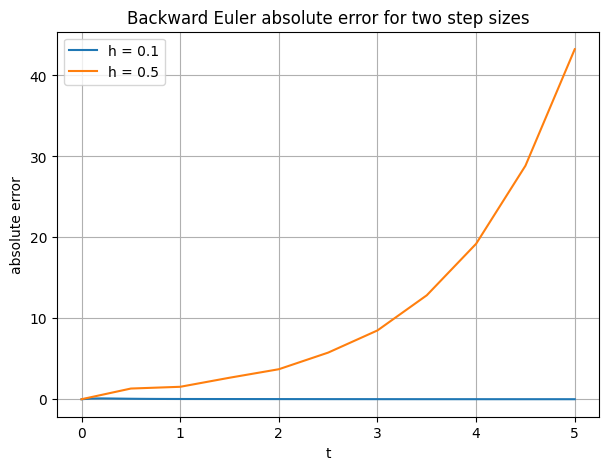

In [ ]:
def feuler3(y0, v0, t_max, dt):
    t = np.arange(0, t_max + dt, dt)
    y = np.zeros_like(t)
    v = np.zeros_like(t)
    y[0] = y0
    v[0] = v0

    for i in range(len(t) - 1):
        y[i+1] = y[i] + dt*v[i]
        v[i+1] = v[i] + dt*(10-6*v[i]-5*y[i])
    return t, y



for dt in dts2:
    t, y = feuler3(y0, v0, 10, dt)
    y_ex = y_exact(t)

    plt.figure(figsize=(5,4))
    plt.plot(t, y, label=f"Euler dt={dt}")
    plt.plot(t, y_ex, label="Analytic")
    plt.legend()
    plt.xlabel("t")
    plt.ylabel("y")
    plt.title(f"Euler Method dt={dt}")

plt.show()

plt.figure(figsize=(7,5))

for dt in dts2:
    t, y_num = feuler3(y0, v0, t_max, dt)
    y_ex = y_exact(t)
    error = np.abs(y_num - y_ex)

    plt.plot(t, error, label=f"h = {dt}")

plt.xlabel("t")
plt.ylabel("absolute error")
plt.title("Forward Euler absolute error for two step sizes")
plt.grid(True)
plt.legend()
# plt.yscale("log")
plt.show()

## Exercise 3 - More Oscillators:

Consider again a system of a mass that is attached to a spring. We have seen (look at Exercise Sheet 6 Exercise Number 3) that the resuling ODE describing such a system is of the form

$$ \frac{d^2 x}{dt^2} = - \frac{k}{m} x \ , $$

where $m$ is the mass of your particle, $k$ is the spring constant, and $x$ is the displacement from the equilibrium position.

**(A)** Implement the Leapfrog integration in oder to solve this ODE. Follow the section "Algorithm" under https://en.wikipedia.org/wiki/Leapfrog_integration. Consider the same values for the constants and initial conditions from Exercise Sheet 6 and plot your result by comparing with the analytic solution. Is the accuracy the same as for the Kunge-Kutta method? Why is this integrator called leapfrog? Name one advantage of the leapfrog integration over other methods such as Kunge-Kutta.

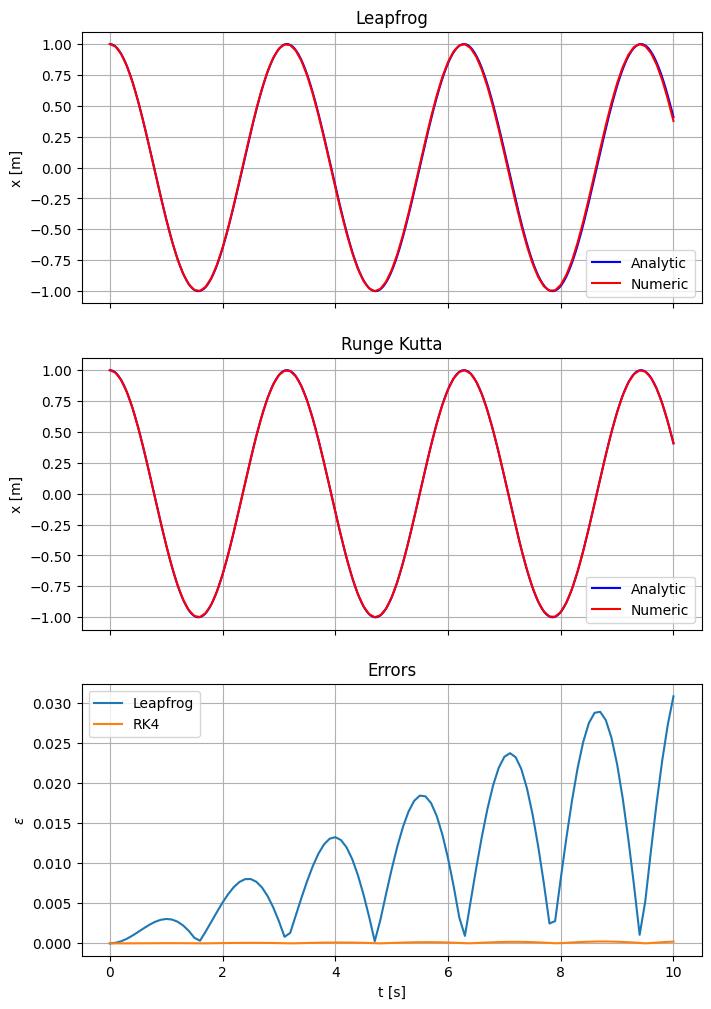

In [7]:
m = 1.0
k = 4.0
x0 = 1.0
v0 = 0

# analytic solution
omega = np.sqrt(k/m)
x_exact = lambda t: x0 * np.cos(omega * t) + v0/omega * np.sin(omega * t)


def leapfrog(x0, v0, t_max, dt):
    t = np.arange(0, t_max + dt, dt)
    x = np.zeros_like(t)
    v = np.zeros_like(t)
    a = np.zeros_like(t)

    x[0] = x0
    v[0] = v0
    a[0] = -k/m * x0

    for i in range(len(t) - 1):
        x[i+1] = x[i] + v[i]*dt + 1/2 * a[i] * dt**2
        a[i+1] = -k/m*x[i+1]
        v[i+1] = v[i] + 1/2*(a[i] + a[i+1])*dt
    return t, x


def rk4(x0, v0, t_max, dt):
    t = np.arange(0, t_max + dt, dt)
    x = np.zeros_like(t)
    v = np.zeros_like(t)

    x[0] = x0
    v[0] = v0

    for i in range(len(t) - 1):
        # k1
        k1x = v[i]
        k1v = -(k/m) * x[i]

        # k2
        k2x = v[i] + 0.5*dt*k1v
        k2v = -(k/m) * (x[i] + 0.5*dt*k1x)

        # k3
        k3x = v[i] + 0.5*dt*k2v
        k3v = -(k/m) * (x[i] + 0.5*dt*k2x)

        # k4
        k4x = v[i] + dt*k3v
        k4v = -(k/m) * (x[i] + dt*k3x)


        x[i+1] = x[i] + (dt/6)*(k1x + 2*k2x + 2*k3x + k4x)
        v[i+1] = v[i] + (dt/6)*(k1v + 2*k2v + 2*k3v + k4v)

    return t, x


dt = 0.1
t_max = 10
t_an = np.linspace(0, t_max, 500)

t_l, x_l = leapfrog(x0, v0, t_max, dt)
t_rk4, x_rk4 = rk4(x0, v0, t_max, dt)
x_analytic = x_exact(t_an)


fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 12), sharex=True)


ax1.plot(t_an, x_analytic, label="Analytic", linestyle="-", color="blue")
ax1.plot(t_l, x_l, label="Numeric", linestyle="-", color="red")
ax1.set_ylabel("x [m]")
ax1.set_title("Leapfrog")
ax1.grid(True)
ax1.legend()


ax2.plot(t_an, x_analytic, label="Analytic", linestyle="-", color="blue")
ax2.plot(t_rk4, x_rk4, label="Numeric", linestyle="-", color="red")
ax2.set_ylabel("x [m]")
ax2.set_title("Runge Kutta")
ax2.grid(True)
ax2.legend()

# error
x_ex = x_exact(t_l)
error_l = np.abs(x_l - x_ex)
error_rk4 = np.abs(x_rk4 - x_ex)

ax3.plot(t_l, error_l, label="Leapfrog")
ax3.plot(t_l, error_rk4, label="RK4")
ax3.grid(True)
ax3.set_title("Errors")
ax3.set_xlabel("t [s]")
ax3.set_ylabel("$\\epsilon$")
ax3.legend()

plt.show()

# Leapfrog scales errors O(dt^2) and Runge-Kutta O(dt^4) (more accurate)
# x_i, x_i+1 and v_i+1/2, v_i-1/2 (positions and velocities leap over each other)
# Leapfrog is stable for oscillatory motion, as long as the time-step Δt is constant, and Δ t < 2/ω ("simplectic" property)

Consider now the damped oscillator of the form:

$$ \frac{d^2 x}{dt^2} = - \frac{k}{m} x - \frac{D}{m} \frac{dx}{dt} \ , $$

where $D$ is an additional friction coefficient.

**(B)**
Solve this ODE with the Runge-Kutta method. Either use the build-in python function or your own implementation. Play around with different values for $D$ and compare it to the analytic solution (you may use : https://lemesurierb.people.charleston.edu/numerical-methods-and-analysis-python/main/ODE-IVP-4-system-higher-order-equations-python.html#equation-equation-damped-mass-spring to help you with the analytic solution). Consider all three possibilities of the system being (1) underdamped, (2) overdamped and (3) critically damped (What do these terms mean?). Make a plot for all three cases to show your numerical and analytic solution.

### Analytic solution

$$
\lambda^2 + \frac{D}{m}\,\lambda + \frac{k}{m} = 0
$$

$$
\gamma \coloneqq \frac{D}{2m}, 
\qquad
\omega \coloneqq \sqrt{\frac{k}{m}}
$$

$$
\lambda_{1,2}
= -\,\gamma
\pm
\sqrt{\gamma^2 - \omega^2}
$$

$$
x(t) = C_1 e^{\lambda_1 t} + C_2 e^{\lambda_2 t}
$$

$$
x(0)=x_0=C_1 + C_2,
\qquad
\dot{x}(0)=v_0=\lambda_1 C_1 + \lambda_2 C_2
$$

$$
C_2 = \frac{v_0 - \lambda_1 x_0}{\lambda_2 - \lambda_1},
\qquad
C_1 = x_0 - C_2
$$

$$
x(t) =
\left(
x_0 - \frac{v_0 - \lambda_1 x_0}{\lambda_2 - \lambda_1}
\right)e^{\lambda_1 t}
+
\frac{v_0 - \lambda_1 x_0}{\lambda_2 - \lambda_1}
\, e^{\lambda_2 t}
$$


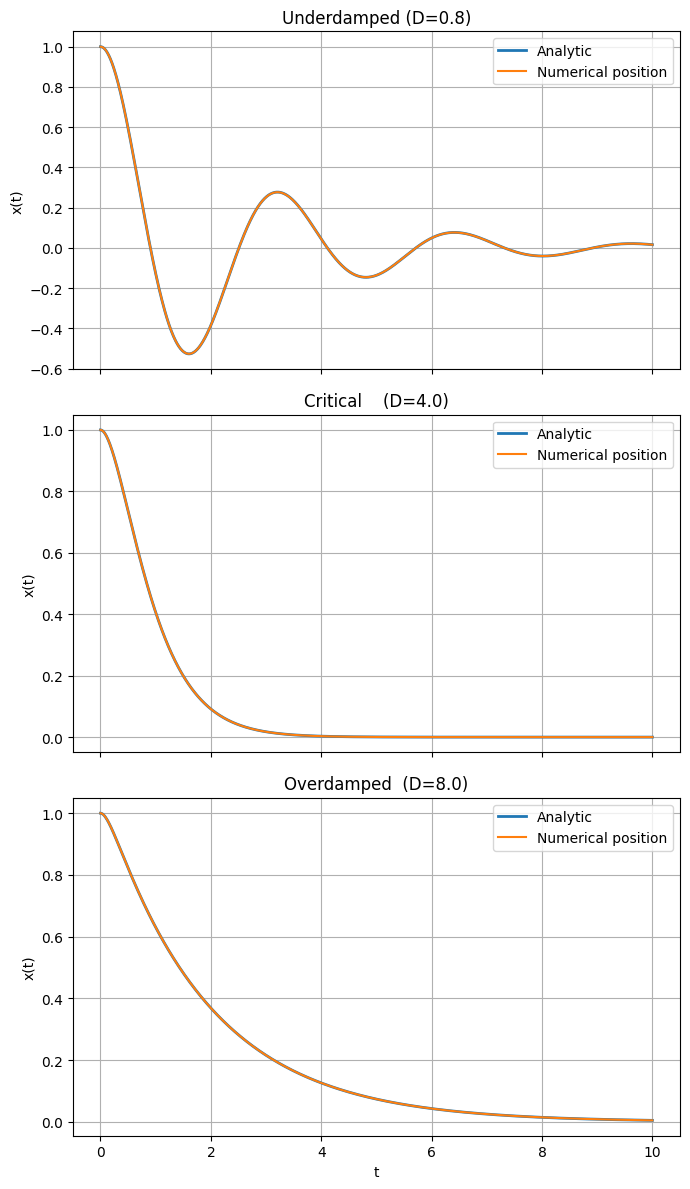

In [4]:
from scipy.integrate import solve_ivp

# analytic solution
def x_analytic(t, D):
    gamma = D/(2*m)

    if np.isclose(gamma, omega):
        C1 = x0
        C2 = v0 + gamma*x0
        return (C1 + C2*t)*np.exp(-gamma*t)

    elif gamma < omega:
        omega_d = np.sqrt(omega**2 - gamma**2)
        C1 = x0
        C2 = (v0 + gamma*x0)/omega_d
        return np.exp(-gamma*t)*(C1*np.cos(omega_d*t) + C2*np.sin(omega_d*t))

    else:
        s = np.sqrt(gamma**2 - omega**2)
        r1 = -gamma + s
        r2 = -gamma - s
        C2 = (v0 - r1*x0)/(r2 - r1)
        C1 = x0 - C2
        return C1*np.exp(r1*t) + C2*np.exp(r2*t)


# ODE system
def rhs(t, y, m, k, D):
    x, v = y
    return [v, -k/m*x - D/m*v] # dx/dt, dv/dt


omega = np.sqrt(k/m)
crit = 2*m*omega

cases = {
    "Underdamped": 0.2*crit, # gamma^2 > omega^2
    "Critical   ": crit, # gamma^2 = omega^2
    "Overdamped ": 2*crit, # gamma^2 < omega^2
}

t_max = 10
t = np.linspace(0, t_max, 1000)

fig, axes = plt.subplots(len(cases), 1, figsize=(7, 12), sharex=True)

for ax, (label, D) in zip(axes, cases.items()):
    sol = solve_ivp(rhs, [0, t_max], [x0, v0], args=(m, k, D),
                    t_eval=t, method="RK45")
    x_num = sol.y[0]
    v_num = sol.y[1]
    x_ex = x_analytic(t, D)

    ax.plot(t, x_ex, label="Analytic", linewidth=2)
    ax.plot(t, x_num, label="Numerical position")
    #ax.plot(t, v_num, label="Numerical velocity")
    ax.set_title(f"{label} (D={D})")
    ax.set_ylabel("x(t)")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()

**(C)**
What problem arises if you were to solve the damped oscillator with the leapfrog algorithm? What could be a possible solution to that problem?

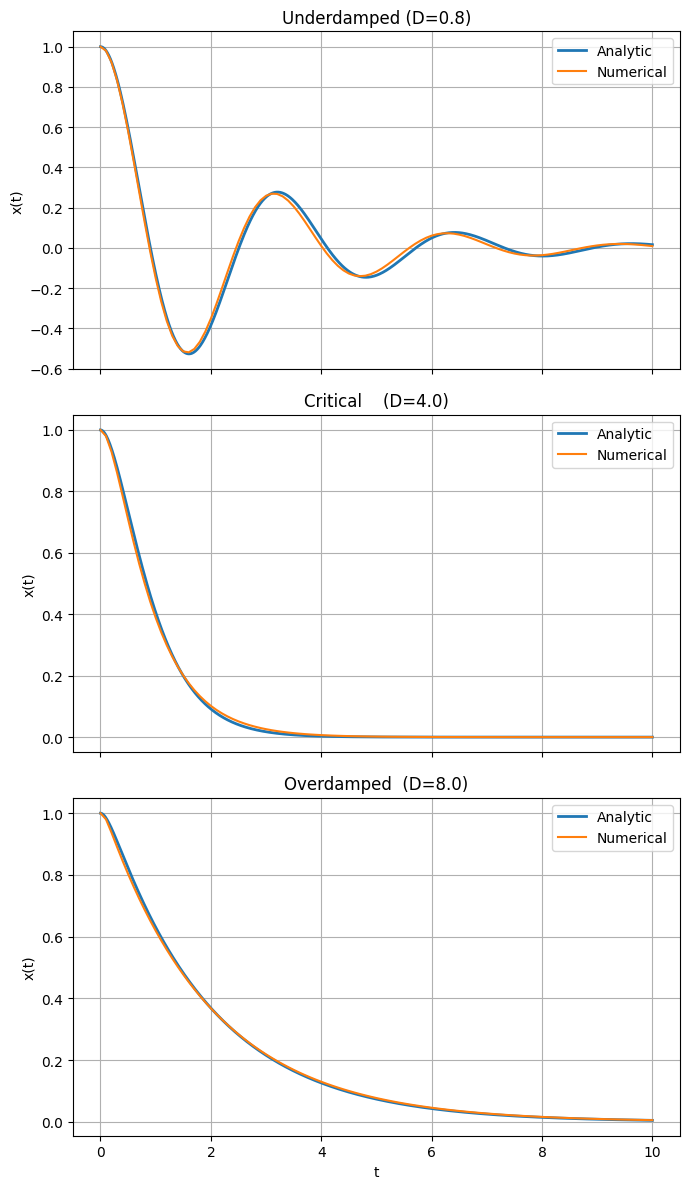

In [5]:
def leapfrog(x0, v0, t_max, dt, D):
    t = np.arange(0, t_max + dt, dt)
    x = np.zeros_like(t)
    v_half = np.zeros_like(t)
    a = np.zeros_like(t)

    x[0] = x0
    a[0] = -k/m * x0 - D/m * v0

    # velocity half step
    v_half[0] = v0 + 0.5 * dt * a[0]

    for i in range(len(t) - 1):
        # x[i+1] = x[i] + v[i]*dt + 1/2 * a[i] * dt**2
        # a[i+1] = -k/m*x[i+1] - D/m * v[i+1]
        # v[i+1] = v[i] + 1/2*(a[i] + a[i+1])*dt
        # does not work, because you need v_i+1 for a_i+1 and vice versa
        # can use the v(i+1/2) notation

        # update position
        x[i+1] = x[i] + dt * v_half[i]

        # compute new acceleration
        a[i+1] = -k/m * x[i+1] - D/m * v_half[i]

        # update half-step velocity
        v_half[i+1] = v_half[i] + dt * a[i+1]
    return t, x


t = np.linspace(0, 10, 1000)

fig, axes = plt.subplots(len(cases), 1, figsize=(7, 12), sharex=True)

for ax, (label, D) in zip(axes, cases.items()):
    t_num, x_num = leapfrog(x0, v0, t_max, dt, D)
    x_ex = x_analytic(t, D)

    ax.plot(t, x_ex, label="Analytic", linewidth=2)
    ax.plot(t_num, x_num, label="Numerical")
    ax.set_title(f"{label} (D={D})")
    ax.set_ylabel("x(t)")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()
